# 08 · Meta GeoLift vs my own implementation

**Question:** on the same data, how does Meta's open-source **GeoLift** (augmented synthetic control) compare with the DiD and placebo inference built in [02](02_difference_in_differences.ipynb)–[04](04_placebo_inference.ipynb)?

**Answer:** GeoLift estimated **7.4%** vs DiD **6.9%** (truth 8%); both 95% intervals cover the truth. On a zero-effect placebo it returned +4.5% but correctly gave **p = 0.61**. Its market-selection shortlist looks strong in history but doesn't reliably hold out-of-sample, and GeoLift itself warns that the pre-period is too short.

| GeoLift function | Role |
|---|---|
| `GeoDataRead` | Formats the panel; dates → time index 1…92 |
| `GeoLiftMarketSelection` | Searches treatment sets ranked by power, MDE, fit, and budget |
| `GeoLift` | Augmented synthetic control + conformal inference |

**Data:** 34 states, 2020-11-01 to 2021-01-31 (time 1–92). Treated: Texas, Florida, Georgia, Arizona, Ohio, Michigan with a **true 8% lift** injected from 2021-01-04 (time 65). Inputs: `data/geolift_pre.csv`, `data/geolift_experiment.csv`.

**Runtime:** Google Colab with an R runtime. Installing `augsynth` and `GeoLift` takes 10–20 minutes.

In [3]:
install.packages("remotes")
remotes::install_github("ebenmichael/augsynth", upgrade = "never")
remotes::install_github("facebookincubator/GeoLift", upgrade = "never")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Skipping install of 'augsynth' from a github remote, the SHA1 (7e700722) has not changed since last install.
  Use `force = TRUE` to force installation

Skipping install of 'GeoLift' from a github remote, the SHA1 (db34ea42) has not changed since last install.
  Use `force = TRUE` to force installation



In [8]:
library(GeoLift)
library(dplyr)

pre_raw <- read.csv("geolift_pre.csv")
exp_raw <- read.csv("geolift_experiment.csv")
head(exp_raw)

,date,location,Y
,<chr>,<chr>,<dbl>
1,2020-11-01,alabama,6
2,2020-11-01,arizona,29
3,2020-11-01,california,260
4,2020-11-01,colorado,22
5,2020-11-01,connecticut,13
6,2020-11-01,florida,69


## Step 1 · Format and plot the data

In [9]:
pre <- GeoDataRead(data = pre_raw, date_id = "date", location_id = "location",
                   Y_id = "Y", format = "yyyy-mm-dd", summary = TRUE)
exp <- GeoDataRead(data = exp_raw, date_id = "date", location_id = "location",
                   Y_id = "Y", format = "yyyy-mm-dd", summary = TRUE)
head(exp)
range(exp$time)     # should be 1 to 92; the test is time 65–92

##################################
#####       Summary       #####
##################################

* Raw Number of Locations: 34
* Time Periods: 64
* Final Number of Locations (Complete): 34

##################################
#####       Summary       #####
##################################

* Raw Number of Locations: 34
* Time Periods: 92
* Final Number of Locations (Complete): 34



,location,time,Y
,<chr>,<int>,<dbl>
1,alabama,1,6
2,alabama,2,21
3,alabama,3,17
4,alabama,4,19
5,alabama,5,12
6,alabama,6,12


[1]  1 92

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the GeoLift package.
  Please report the issue to the authors.”


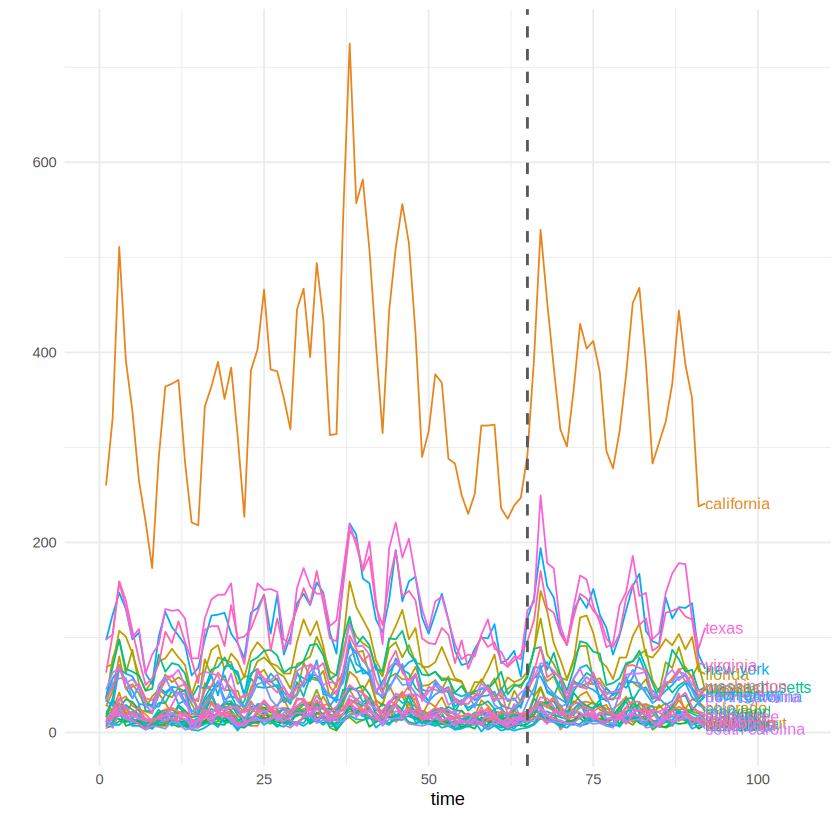

In [10]:
GeoPlot(exp, Y_id = "Y", time_id = "time", location_id = "location", treatment_start = 65)

Map `time` back to calendar dates and plot with and without California:

In [12]:
# time index ↔ calendar date (11/01 = 1)
date_lookup <- data.frame(date = sort(unique(as.Date(exp_raw$date))))
date_lookup$time <- seq_len(nrow(date_lookup))

head(date_lookup)

,date,time
,<date>,<int>
1,2020-11-01,1
2,2020-11-02,2
3,2020-11-03,3
4,2020-11-04,4
5,2020-11-05,5
6,2020-11-06,6


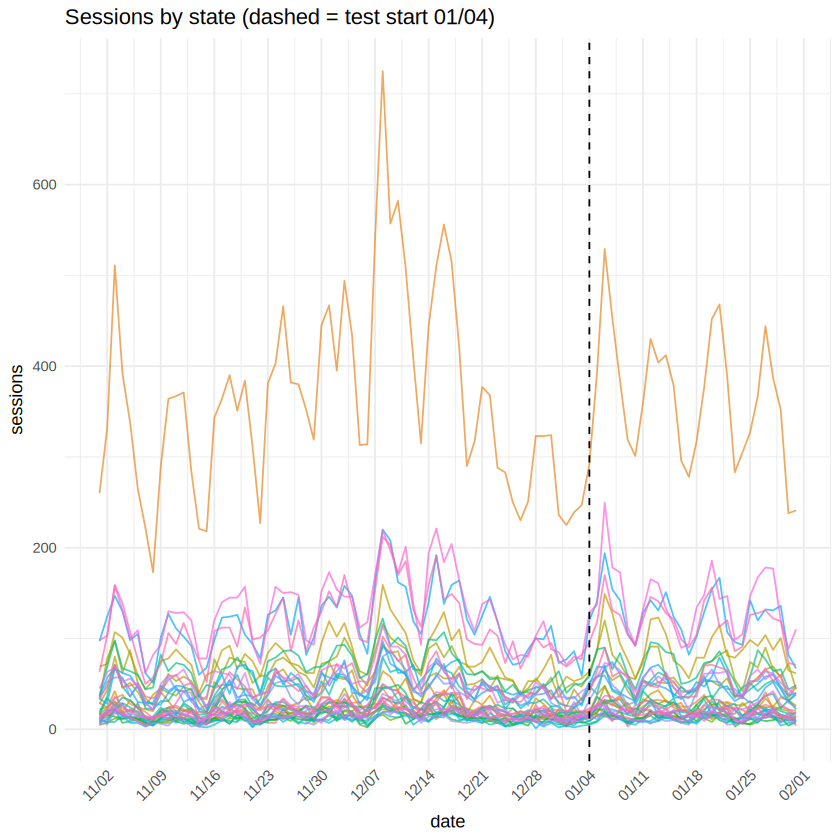

In [13]:
library(ggplot2)

exp_dated <- exp %>% left_join(date_lookup, by = "time")

ggplot(exp_dated, aes(x = date, y = Y, group = location, color = location)) +
  geom_line(alpha = 0.7) +
  geom_vline(xintercept = as.Date("2021-01-04"), linetype = "dashed") +
  scale_x_date(date_breaks = "1 week", date_labels = "%m/%d") +
  labs(x = "date", y = "sessions", title = "Sessions by state (dashed = test start 01/04)") +
  theme_minimal() +
  theme(legend.position = "none", axis.text.x = element_text(angle = 45, hjust = 1))

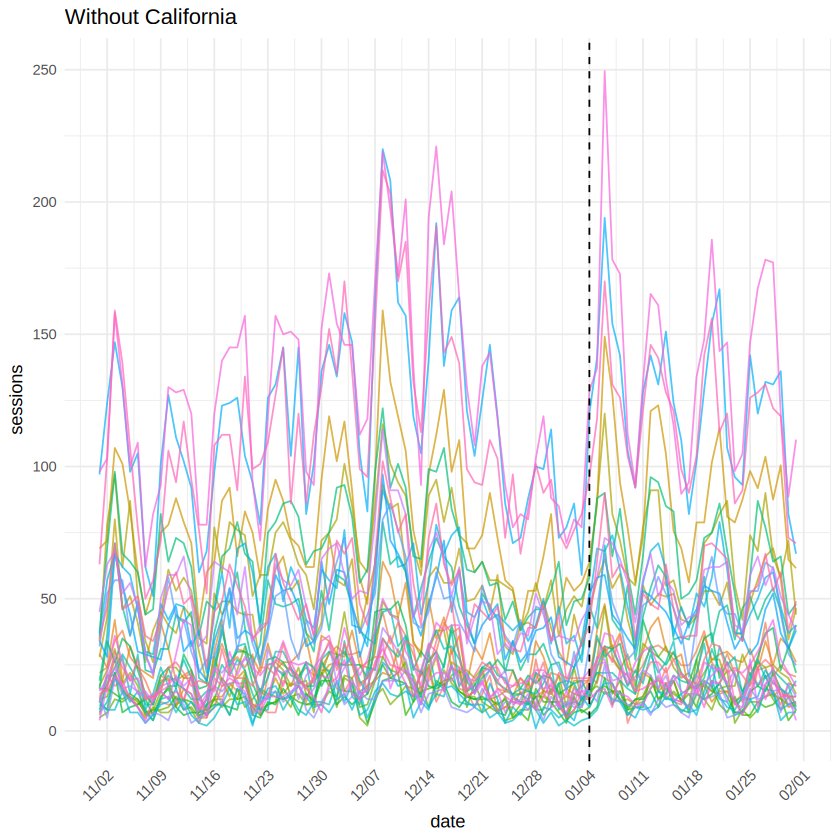

In [14]:
ggplot(exp_dated %>% filter(location != "california"),
       aes(x = date, y = Y, group = location, color = location)) +
  geom_line(alpha = 0.7) +
  geom_vline(xintercept = as.Date("2021-01-04"), linetype = "dashed") +
  scale_x_date(date_breaks = "1 week", date_labels = "%m/%d") +
  labs(x = "date", y = "sessions", title = "Without California") +
  theme_minimal() +
  theme(legend.position = "none", axis.text.x = element_text(angle = 45, hjust = 1))

The plot shows the early-to-mid December peak (time 38–46), the Christmas–New Year drop (55–64), and the January rebound after launch (65). California runs 2–3× Texas and is far more volatile, which is why it is excluded from treatment in [06](06_market_selection.ipynb).

## Step 2 · Market selection (pre-period only)

Settings mirror [05](05_power_analysis_mde.ipynb)–[07](07_iroas_and_profit.ipynb): 6 treated states, 28-day test, California excluded, cost per incremental conversion $1.12, α = 0.05, two-sided.

In [15]:
selection <- GeoLiftMarketSelection(
  data = pre, treatment_periods = c(28), N = c(6),
  Y_id = "Y", location_id = "location", time_id = "time",
  effect_size = seq(0, 0.15, 0.025), lookback_window = 1,
  exclude_markets = c("california"),
  cpic = 1.12, alpha = 0.05, side_of_test = "two_sided",
  fixed_effects = TRUE, Correlations = TRUE
)
head(selection$BestMarkets, 10)

Setting up cluster.

Importing functions into cluster.

Attempting to load the environment ‘package:augsynth’

Attempting to load the environment ‘package:tidyr’

Calculating which the best treatment groups are.

Caution: Small pre-treatment period!.
                   
It's recommended to have at least 4x pre-treatment periods for each treatment period.



Deterministic setup with 6 locations in treatment.



  ID                                                           location
1  1               florida, georgia, new york, oregon, tennessee, texas
2  2 massachusetts, new york, pennsylvania, texas, virginia, washington
3  3           florida, michigan, new york, texas, virginia, washington
4  4            florida, illinois, new york, tennessee, texas, virginia
5  5           florida, illinois, new york, texas, virginia, washington
6  6            florida, illinois, minnesota, new york, texas, virginia
  duration EffectSize Power AvgScaledL2Imbalance Investment   AvgATT
1       28      0.025     1            0.5022217    341.600 2.458357
2       28      0.025     1            0.3646744    431.620 3.175438
3       28      0.025     1            0.3979131    434.392 3.465740
4       28      0.025     1            0.3415852    433.328 3.583575
5       28      0.025     1            0.3497526    453.068 3.691688
6       28      0.025     1            0.3503243    428.568 3.671730
  Average_MDE

,ID,location,duration,EffectSize,Power,AvgScaledL2Imbalance,Investment,AvgATT,Average_MDE,ProportionTotal_Y,abs_lift_in_zero,Holdout,rank,correlation
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,1,"florida, georgia, new york, oregon, tennessee, texas",28,0.025,1,0.5022217,341.600,2.458357,0.03415516,0.2574296,0.009,0.7425704,1,0.9682209
2,2,"massachusetts, new york, pennsylvania, texas, virginia, washington",28,0.025,1,0.3646744,431.620,3.175438,0.03494315,0.3259425,0.010,0.6740575,2,0.9790035
3,3,"florida, michigan, new york, texas, virginia, washington",28,0.025,1,0.3979131,434.392,3.465740,0.03800649,0.3263590,0.013,0.6736410,3,0.9739817
4,4,"florida, illinois, new york, tennessee, texas, virginia",28,0.025,1,0.3415852,433.328,3.583575,0.03944998,0.3252741,0.014,0.6747259,4,0.9754765
5,5,"florida, illinois, new york, texas, virginia, washington",28,0.025,1,0.3497526,453.068,3.691688,0.03884693,0.3405982,0.014,0.6594018,4,0.9764714
6,6,"florida, illinois, minnesota, new york, texas, virginia",28,0.025,1,0.3503243,428.568,3.671730,0.04092747,0.3214673,0.016,0.6785327,6,0.9755097
7,7,"florida, new jersey, new york, texas, virginia, wisconsin",28,0.100,1,0.4080315,1681.008,10.134198,0.11497970,0.3150451,0.015,0.6849549,6,0.9688696
8,8,"connecticut, illinois, nebraska, new york, texas, virginia",28,0.025,1,0.4268653,369.488,3.300522,0.04274690,0.2770255,0.018,0.7229745,8,0.9699016
9,9,"illinois, missouri, new jersey, new york, texas, virginia",28,0.025,1,0.3991851,409.248,3.972474,0.04662390,0.3064822,0.022,0.6935178,9,0.9692730


## Step 3 · Lift estimate

`GeoLift()` fails with multiple treated locations (*"Tibble columns must have compatible sizes"*: 552 = 6 states × 92 days stacked against 92 rows; [facebookincubator/GeoLift#230](https://github.com/facebookincubator/GeoLift/issues/230)). The treated states are aggregated into one unit, which is the same aggregation the DiD uses.

In [17]:
TREATED <- c("texas", "florida", "georgia", "arizona", "ohio", "michigan")

# aggregated 6 states "treatedgroup"
exp_agg_raw <- exp_raw %>%
  mutate(location = ifelse(location %in% TREATED, "treatedgroup", location)) %>%
  group_by(date, location) %>%
  summarise(Y = sum(Y), .groups = "drop")

exp_agg <- GeoDataRead(data = exp_agg_raw, date_id = "date", location_id = "location",
                       Y_id = "Y", format = "yyyy-mm-dd", summary = TRUE)

result <- GeoLift(
  Y_id = "Y", time_id = "time", location_id = "location",
  data = exp_agg, locations = c("treatedgroup"),
  treatment_start_time = 65, treatment_end_time = 92,
  alpha = 0.05, model = "best", fixed_effects = TRUE,
  ConfidenceIntervals = TRUE
)
summary(result)

##################################
#####       Summary       #####
##################################

* Raw Number of Locations: 29
* Time Periods: 92
* Final Number of Locations (Complete): 29

Selected Ridge as best model.


GeoLift Results Summary


##################################
#####     Test Statistics    #####
##################################

* Average ATT: 27.141
* Percent Lift: 7.4%
* Incremental Y: 760
* P-value: 0.03
* 95% Confidence Interval: (244.556, 1154.048)

##################################
#####   Balance Statistics   #####
##################################

* L2 Imbalance: 211.48
* Scaled L2 Imbalance: 0.2809
* Percent improvement from naive model: 71.91%
* Average Estimated Bias: 3.95

##################################
#####     Model Weights      #####
##################################

* Prognostic Function: RIDGE

* Model Weights:

 * california: 0.7206

 * new york: 0.4673

 * washington: 0.23

 * virginia: 0.1618

 * kansas: -0.15

 * alabama: -0.1

You can include dates in your chart if you supply the end date of the treatment. Just specify the treatment_end_date parameter.

Warning message:
“Removed 64 rows containing missing values or values outside the scale range
(`geom_ribbon()`).”


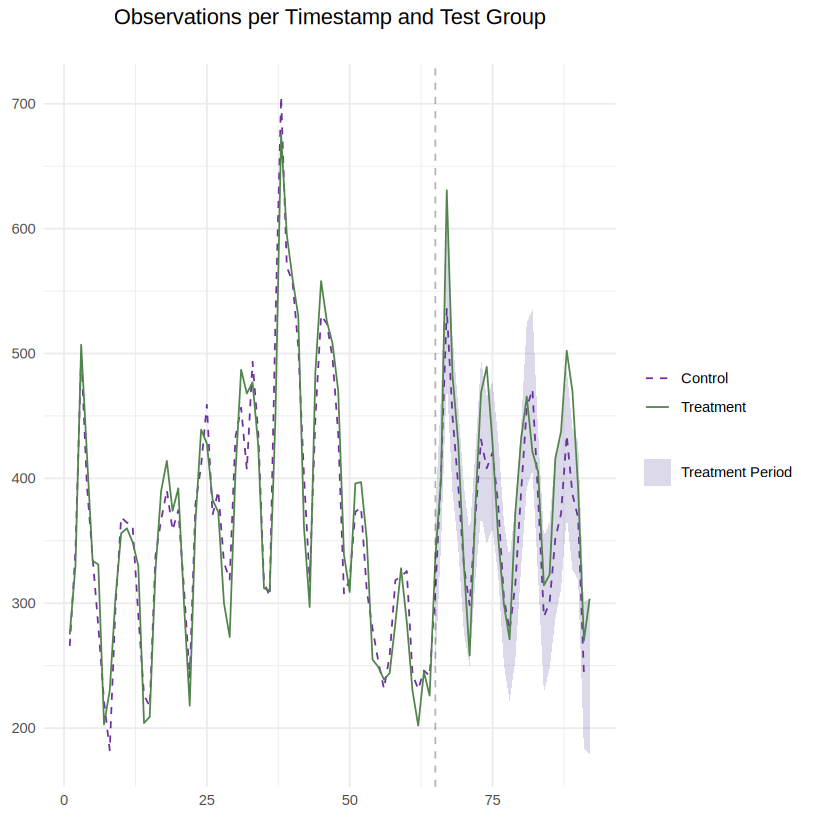

In [18]:
plot(result, type = "Lift")      # treated vs synthetic control over time

You can include dates in your chart if you supply the end date of the treatment. Just specify the treatment_end_date parameter.

Warning message:
“Removed 64 rows containing missing values or values outside the scale range
(`geom_ribbon()`).”


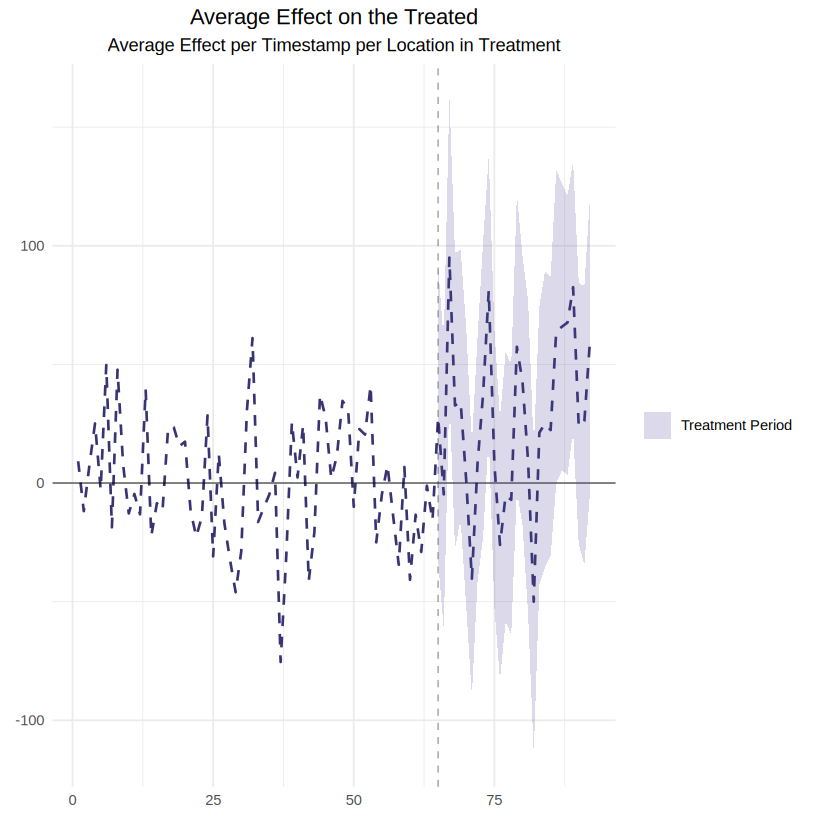

In [19]:
plot(result, type = "ATT")       # daily incremental effect

## Step 4 · Placebo: six untreated states (true effect = 0)

The real treated states are dropped first so their injected lift can't contaminate the control pool.

In [20]:
PLACEBO <- c("virginia", "new york", "illinois", "pennsylvania", "washington", "north carolina")

placebo_raw <- exp_raw %>%
  filter(!location %in% TREATED) %>%
  mutate(location = ifelse(location %in% PLACEBO, "placebogroup", location)) %>%
  group_by(date, location) %>%
  summarise(Y = sum(Y), .groups = "drop")

placebo_data <- GeoDataRead(data = placebo_raw, date_id = "date", location_id = "location",
                            Y_id = "Y", format = "yyyy-mm-dd", summary = TRUE)

placebo <- GeoLift(
  Y_id = "Y", time_id = "time", location_id = "location",
  data = placebo_data, locations = c("placebogroup"),
  treatment_start_time = 65, treatment_end_time = 92,
  alpha = 0.05, model = "best", fixed_effects = TRUE
)
summary(placebo)

##################################
#####       Summary       #####
##################################

* Raw Number of Locations: 23
* Time Periods: 92
* Final Number of Locations (Complete): 23

Selected Ridge as best model.


GeoLift Results Summary


##################################
#####     Test Statistics    #####
##################################

* Average ATT: 19.984
* Percent Lift: 4.5%
* Incremental Y: 560
* P-value: 0.61

##################################
#####   Balance Statistics   #####
##################################

* L2 Imbalance: 303.489
* Scaled L2 Imbalance: 0.3175
* Percent improvement from naive model: 68.25%
* Average Estimated Bias: 0.116

##################################
#####     Model Weights      #####
##################################

* Prognostic Function: RIDGE

* Model Weights:

 * california: 1.0808

 * iowa: -0.0103

 * louisiana: -0.0093

 * wisconsin: -0.0089

 * massachusetts: 0.0077

 * kentucky: -0.0073

 * new jersey: 0.0072

 * minn

## Findings

**Market selection**
- GeoLift warns: *"Small pre-treatment period"* (it recommends ≥ 4× the test length: 112 days; we have 64).
- Top set (Florida, Georgia, New York, Oregon, Tennessee, Texas): **MDE 2.5%** (average 3.4%), investment ≈ $342, budget share 25.7%, placebo bias 0.9%. That's better than the 6% MDE for random 6-state sets in [05](05_power_analysis_mde.ipynb).
- New York and Texas appear in all 10 top sets, mostly large states, so the shortlist covers **26–34%** of traffic vs 12–16% for stratified draws. Lower MDE, higher cost.
- Out-of-sample (January, zero-lift DiD): the #1 set has 0.1% error, but #2–#5 have 1.9–2.9%, **worse than the random-set median of 1.3%**, consistent with [06](06_market_selection.ipynb).

**Lift estimate (true lift 8%)**

| | DiD ([04](04_placebo_inference.ipynb)) | GeoLift (ridge ASCM) | Truth |
|---|---|---|---|
| Lift | 6.9% | **7.4%** | 8% |
| 95% CI | [2.8%, 10.5%] | **[2.3%, 11.6%]** (245–1,154 sessions) | |
| p-value | < 0.001 | **0.03** | |
| Incremental sessions | 716 | **760** | ≈ 820 |

- The 0.5-point gap is small next to ~9-point interval widths. GeoLift's conformal inference is more conservative.
- `model = "best"` selected **ridge** augmentation: weights sum to ≈ 1 but include negatives (+1.98 / −0.98), letting the synthetic unit extrapolate beyond the donors (needed for a large aggregated group). California gets the largest weight (0.72). Pre-period fit improves 72% over the naive model.

**Placebo (Virginia, New York, Illinois, Pennsylvania, Washington, North Carolina)**

| | Lift | p-value |
|---|---|---|
| GeoLift | +4.5% | **0.61** (correctly not significant) |
| DiD, same placebo | +3.2% | |

- The p-value separated the real test (0.03) from the placebo (0.61), but the +4.5% point estimate alone would mislead.
- The placebo counterfactual is essentially **1.08 × California** (all other weights ≈ ±0.01), a fragile single-donor dependence.
- Across the two tests, GeoLift and DiD each came closer once: model sophistication didn't guarantee accuracy.

## Takeaways

- GeoLift is fast and standard: one function covers market selection, power, and budget, plus augmented SCM and conformal inference out of the box.
- Its outputs still need checking: validate rankings out-of-sample, inspect weights for extrapolation or single-donor dependence, and never report a point estimate without its interval.